In [1]:
from polygon import RESTClient
import pandas as pd
import numpy as np
import sklearn
import scipy
import matplotlib.pyplot as plt
import collections

import datetime

from tqdm import tqdm

from constants import api_key

import time

client = RESTClient(api_key = api_key)

import pyspark
from pyspark.sql.window import Window

import os
import sys

from sklearn.linear_model import LinearRegression, Ridge, Lasso

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

In [2]:
# spark = (
#     pyspark
#     .sql
#     .SparkSession
#     .builder
#     .appName('sparksession')
#     .config("spark.driver.memory", "8g")
#     .config("spark.executor.memory", "16g")
#     .config("spark.executor.cores", "4")
#     .config("spark.network.timeout", "600s") \
#     .getOrCreate()
# )
# spark.sparkContext.setLogLevel("ERROR")  # Only show errors, suppress warnings and info

In [3]:
ticker = 'I:SPX'
price_performance = collections.defaultdict(list)

for agg in tqdm(client.list_aggs(ticker=ticker, multiplier=1, timespan="minute", from_="2023-10-16", to="2024-11-01", limit=50000)):
    if datetime.datetime.fromtimestamp(agg.timestamp/1000).time()>=datetime.time(9, 30) and datetime.datetime.fromtimestamp(agg.timestamp/1000).time()<=datetime.time(16,0):
        price_performance['Open'].append(agg.open)
        price_performance['Close'].append(agg.close)
        price_performance['high'].append(agg.high)
        price_performance['low'].append(agg.low)
        price_performance['volume'].append(agg.volume)
        price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
        price_performance['transactions'].append(agg.transactions)

ticker_hist = pd.DataFrame(price_performance)

102963it [00:02, 42336.91it/s]


In [4]:
ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)


ticker_hist['logClose'] = np.log(ticker_hist['Close'])
ticker_hist['logOpen'] = np.log(ticker_hist['Open'])

ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']


ab_params = {}

ab_params['a'] = {}
ab_params['b'] = {}


print('analyzing')

dates = ticker_hist['Date'].unique()

for index, date in tqdm(enumerate(dates)):
    ticker_hist_date = ticker_hist[ticker_hist['Date'] == date]
    logReturns = ticker_hist_date['logReturns']
    #counts, bin_edges = np.histogram(ticker_hist_date['logReturns'], bins=100)
    a = np.median(logReturns)
    b = np.sum(
            np.abs(logReturns - a)
    ) / (len(logReturns))
    ab_params['a'][date] = a
    ab_params['b'][date] = b

analyzing


264it [00:00, 315.74it/s]


In [5]:
ab_params_df = pd.DataFrame(ab_params)

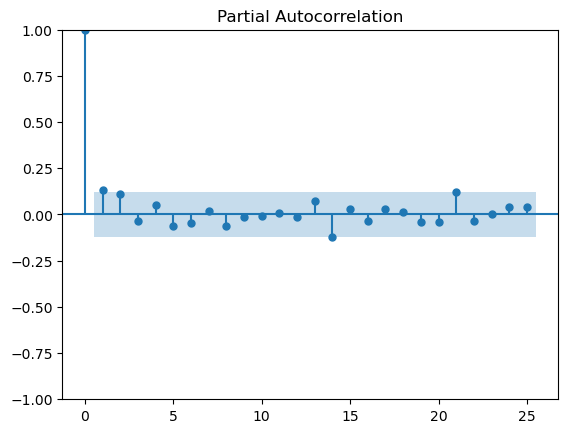

In [6]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['a']
)
plt.show()

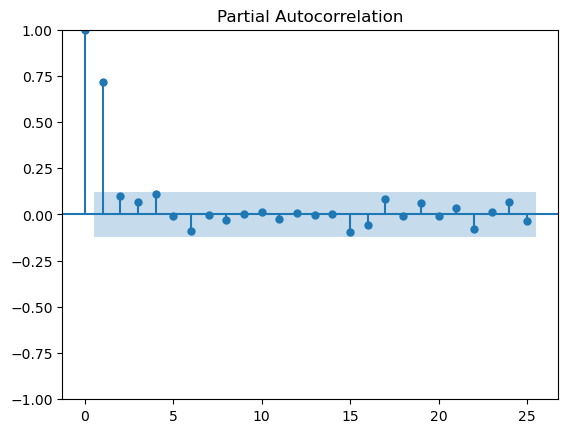

In [7]:
import statsmodels.tsa

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['b']
)
plt.show()

In [8]:
scipy.stats.spearmanr(ab_params_df['a'].shift(-1).iloc[:-1], ab_params_df['a'].iloc[:-1])

SignificanceResult(statistic=np.float64(0.1275593106956179), pvalue=np.float64(0.038709377020140684))

In [9]:
scipy.stats.pearsonr(ab_params_df['b'].shift(-1).iloc[:-1], ab_params_df['b'].iloc[:-1])

PearsonRResult(statistic=np.float64(0.7194287187775346), pvalue=np.float64(3.3263258701729997e-43))

In [10]:
scipy.stats.spearmanr(ab_params_df['b'].shift(-2).iloc[:-2], ab_params_df['b'].iloc[:-2])

SignificanceResult(statistic=np.float64(0.46327347167272026), pvalue=np.float64(2.412916747274962e-15))

In [11]:
scipy.stats.spearmanr(ab_params_df['b'].shift(-1).iloc[:-1], ab_params_df['a'].iloc[:-1])

SignificanceResult(statistic=np.float64(-0.19109476124104702), pvalue=np.float64(0.001851883499494162))

In [12]:
ab_params_df['shifted_a_1'] = ab_params_df['a'].shift(-1)
ab_params_df['shifted_b_1'] = ab_params_df['b'].shift(-1)



In [13]:
lr_b = LinearRegression()

lr_b.fit(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_b_1'])
print(lr_b.score(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_b_1']))

lr_a = LinearRegression()

lr_a.fit(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_a_1'])
print(lr_a.score(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_a_1']))


0.5236008436389481
0.017505520530248897


In [14]:
ab_params_df['shifted_a_2'] = ab_params_df['a'].shift(-2)
ab_params_df['shifted_b_2'] = ab_params_df['b'].shift(-2)

In [15]:
r_b = LinearRegression()

r_b.fit(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_b_2'])
print(r_b.score(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_b_2']))

r_a = LinearRegression()

r_a.fit(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_a_2'])
print(r_a.score(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_a_2']))


0.5336802355963615
0.03629080239907889


In [16]:
r_b.coef_

array([ 0.01265914,  0.15196692, -0.45002982,  0.57392852])

In [17]:
lr_b.coef_

array([-0.30930618,  0.69479318])

In [18]:
lr_a.coef_

array([0.13731868, 0.00636668])

In [19]:
r_a.coef_

array([ 0.11282296, -0.02706923,  0.15609938,  0.03603315])

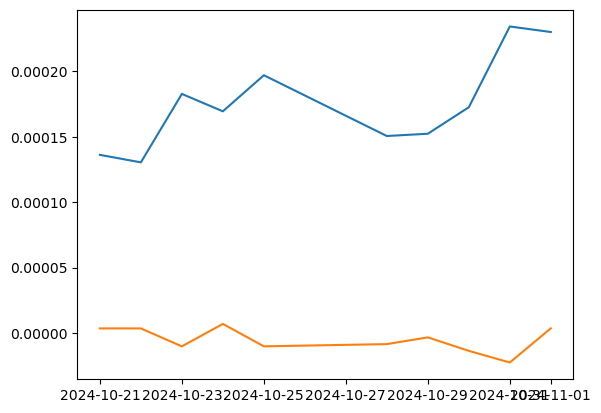

In [23]:
plt.plot(ab_params_df['b'][-10:])
plt.plot(ab_params_df['a'][-10:])

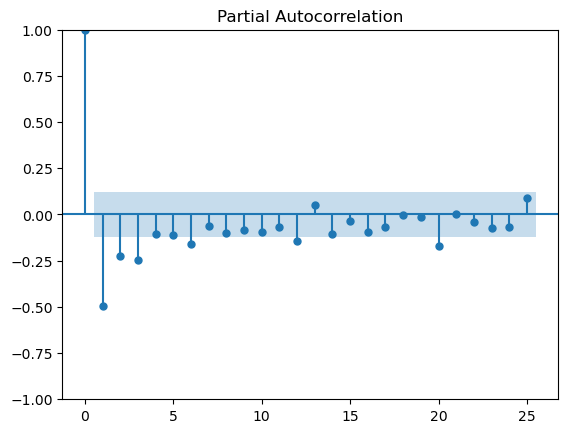

In [25]:
statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['a'].diff()[1:]
)
plt.show()

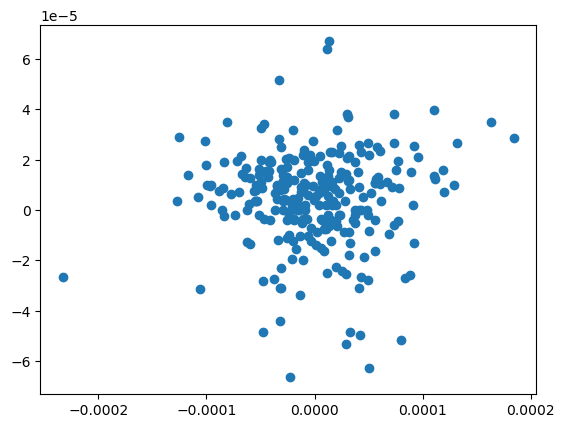

In [39]:
plt.scatter(ab_params_df['b'].diff(), ab_params_df['shifted_a_1'])

In [40]:
ab_params_df['b'].diff()

2023-10-16         NaN
2023-10-17    0.000029
2023-10-18    0.000049
2023-10-19    0.000088
2023-10-20   -0.000084
                ...   
2024-10-28   -0.000046
2024-10-29    0.000002
2024-10-30    0.000020
2024-10-31    0.000062
2024-11-01   -0.000004
Name: b, Length: 264, dtype: float64

In [34]:
scipy.stats.pearsonr(ab_params_df['b'].diff()[1::-1], ab_params_df['a'].shift(-1)[1::-1])

PearsonRResult(statistic=np.float64(nan), pvalue=np.float64(1.0))

In [41]:
replicates = 100000

In [42]:
possible_final_returns = np.zeros(replicates)
for r in tqdm(range(replicates)):
    samples = np.random.laplace(
        loc=r_a.predict(ab_params_df[
            ['a', 'b', 'shifted_a_1', 'shifted_b_1']
            ].dropna()
        )[-1], 
        scale=r_b.predict(
            ab_params_df[
                ['a', 'b', 'shifted_a_1', 'shifted_b_1']
            ].dropna()
        )[-1],
        size=len(ticker_hist_date)
    )

    possible_final_returns[r] = samples.sum()


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [01:28<00:00, 1130.67it/s]


In [43]:
r_a.predict(ab_params_df[['a', 'b', 'shifted_a_1', 'shifted_b_1']].dropna())[-1]

np.float64(1.2169074851505253e-06)

In [44]:
r_b.predict(ab_params_df[['a', 'b', 'shifted_a_1', 'shifted_b_1']].dropna())[-1]

np.float64(0.0002222707669128286)

In [45]:
np.std(possible_final_returns)

np.float64(0.0062167263214174835)

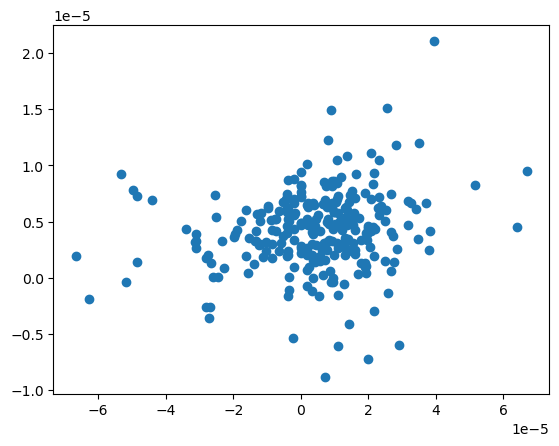

In [47]:
plt.scatter(
    ab_params_df.dropna()['shifted_a_2'], 
    r_a.predict(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']]
    )
)

(0.0, 20.0)

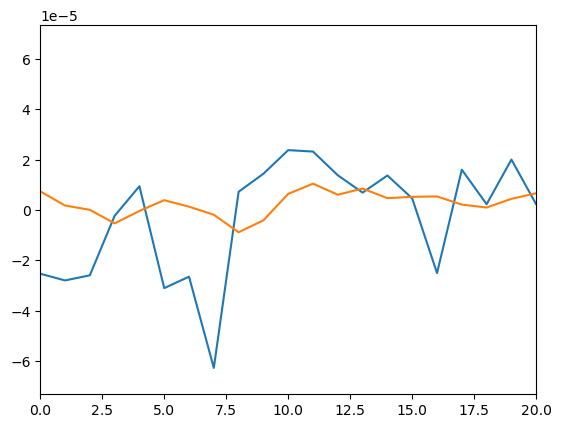

In [48]:
plt.plot(ab_params_df.dropna()['shifted_a_2'].reset_index(drop=True))
plt.plot(r_a.predict(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']]))

plt.xlim(0,20)

# declare spot ticker price

In [49]:
spot_spx_price = 5725.

In [50]:
upper_call = 5780.
lower_call = 5775.
upper_put = 5690.
lower_put = 5685.

In [51]:
possible_final_prices = spot_spx_price * np.exp(np.asarray(possible_final_returns))

In [52]:
print(np.mean(possible_final_prices))
print(np.std(possible_final_prices))



5727.745237910002
35.60766359327889


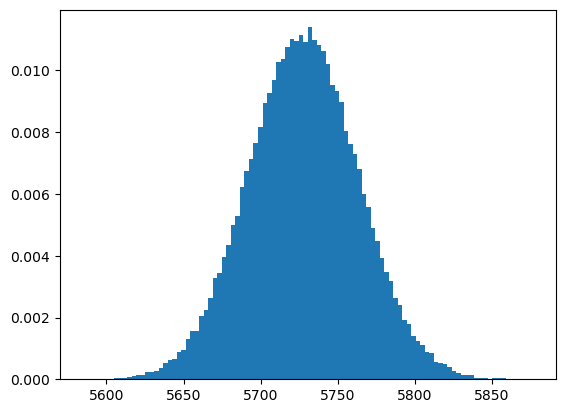

In [53]:
plt.hist(possible_final_prices, bins = 100, density = True)

plt.show()

In [54]:
payouts = np.zeros(replicates)
for index, price in enumerate(possible_final_prices):
    payout = (
        np.max([0., lower_put - price])
        - np.max([0., upper_put - price])
        - np.max([0., price - lower_call])
        + np.max([0., price - upper_call])
    )

    payouts[index] = payout

In [55]:
len(ticker_hist_date)

391

In [56]:
6.5*60

390.0

Text(0.5, 1.0, 'avg payout is -1.05')

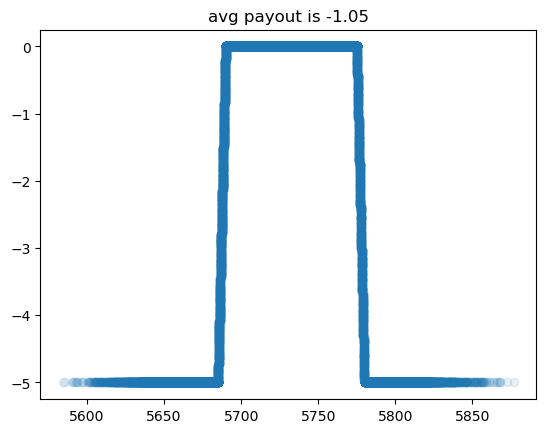

In [57]:
plt.scatter(possible_final_prices, payouts, alpha=0.1)
mean_payout = np.round(np.mean(payouts), 2)
plt.title(f'avg payout is {mean_payout}')

# compute cost of trade and max loss

In [113]:
cost_of_trade = 1.1
max_loss = 5

In [114]:
p = (max_loss - cost_of_trade)/max_loss

In [115]:
fstar = p - (1-p)/(cost_of_trade/(max_loss-cost_of_trade))
print(f'Kelly Criterion prediction, assuming fair odds, is {fstar}')

Kelly Criterion prediction, assuming fair odds, is 2.220446049250313e-16


In [116]:
my_p = sum(payouts > -cost_of_trade)/len(payouts)

fstar_me = my_p - (1 - my_p)/(cost_of_trade/(max_loss-cost_of_trade))

print(f'Kelly Criterion prediction, assuming my odds, is {fstar_me}')

Kelly Criterion prediction, assuming my odds, is 0.4729545454545455
